In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/Users/namithageorge/msai339/project/National-Parks-DS/Datasets/national_parks_cleaned.csv")

# separating date column into two columns 'Year' and 'Month'
df['date'] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str)) 
# print(df.head())

# running sarima for one park - Acadia National Park
parks = df['ParkName'].unique()

acadia_df = df[df['ParkName'] == parks[0]].copy()
# print(park_df.head())
acadia_df = acadia_df.set_index("date").asfreq("MS")
model_acadia = SARIMAX(acadia_df["RecreationVisits"], order=(0,1,1), seasonal_order=(0,1,1,12))
results_acad = model_acadia.fit()
print(results_acad.summary())

# yellowstone_df = df[df['ParkName'] == 'Yellowstone NP'].copy()
# yellowstone_df = yellowstone_df.set_index("date").asfreq("MS")
# model_yellowstone = SARIMAX(yellowstone_df['RecreationVisits'], order=(0,1,1), seasonal_order=(0,1,1,12))
# results_yell = model_yellowstone.fit()



# for park in parks:
#     park_df = df[df['ParkName'] == park].copy()
#     park_df = park_df.set_index("date").asfreq("MS")
#     model = SARIMAX(park_df["RecreationVisits"], order=(0,1,1), seasonal_order=(0,1,1,12))
#     results = model.fit()
#     # print(results.summary())
#     # print(park_df)

/var/folders/5n/0jwm44bd7m76wp2nkfsyxtph0000gn/T/ipykernel_42855/2642252049.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str))


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.19548D+01    |proj g|=  7.40556D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      3      5      1     0     0   6.618D-06   1.195D+01
  F =   11.954753260594892     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
                                     SARIMAX Results                                      
Dep. Variable:                   RecreationVisits   No. Observations:                  560
Model:      

 This problem is unconstrained.
 This problem is unconstrained.



           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      4      6      1     0     0   5.318D-06   1.192D+01
  F =   11.919973428866538     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


In [ ]:
parks = df['ParkName'].unique()

for park in parks:
    
    # Filter to park
    park_df = df[df['ParkName'] == park].copy()
    park_df = park_df.set_index("date").asfreq("MS")
    
    park_df['Year'] = park_df.index.year
    park_df['Month'] = park_df.index.month
    
    fig, axes = plt.subplots(4, 3, figsize=(14, 10))
    axes = axes.flatten()
    
    month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']
    
    for month in range(1, 13):
        ax = axes[month - 1]
        monthly = park_df[park_df['Month'] == month]
        
        ax.plot(monthly['Year'], monthly['RecreationVisits'],
                marker='o', linewidth=1, alpha=0.7)
        
        ax.set_title(month_names[month - 1])
        ax.grid(alpha=0.3)
    
    plt.suptitle(f"Seasonal Subseries Plot – {park}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Save each figure
    plt.savefig(f"subseries_{park.replace(' ', '_')}.png", dpi=150)
    plt.close()


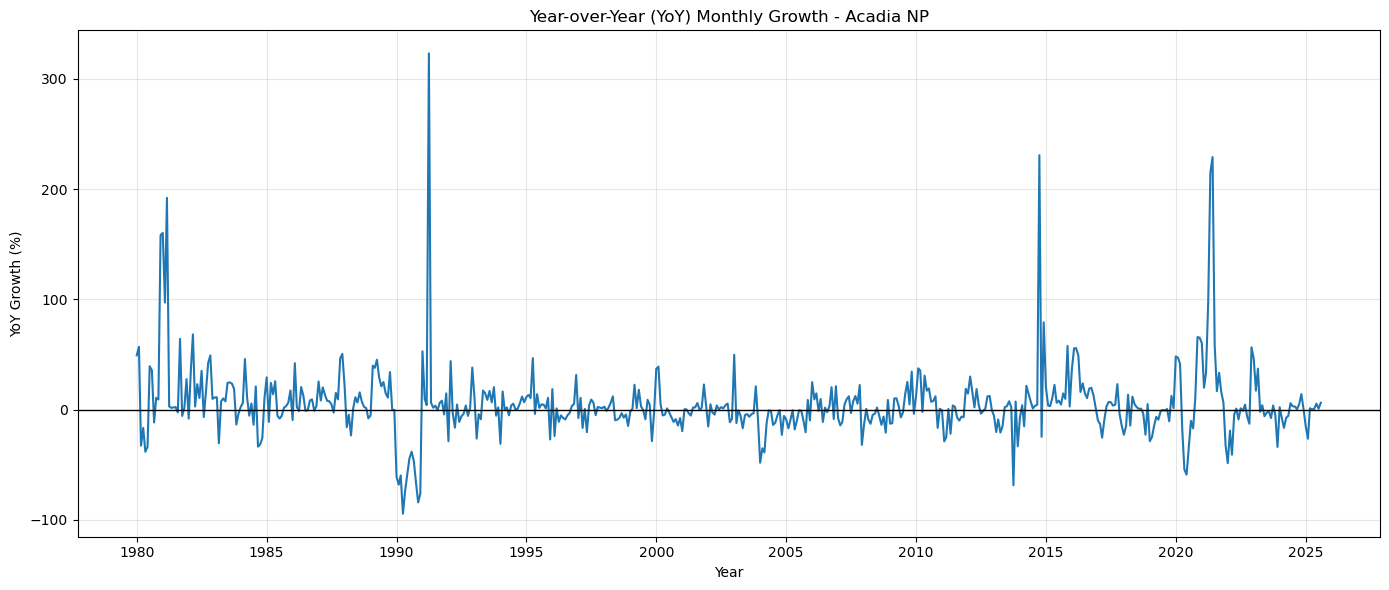

In [ ]:
df_yoy = park_df.copy()
df_yoy['Month'] = df_yoy.index.month
df_yoy['Year'] = df_yoy.index.year

df_yoy['YoY_Growth'] = df_yoy['RecreationVisits'].pct_change(12) * 100

plt.figure(figsize=(14, 6))
plt.plot(df_yoy.index, df_yoy['YoY_Growth'], linewidth=1.5)

plt.axhline(0, color='black', linewidth=1) 

plt.title(f"Year-over-Year (YoY) Monthly Growth - {parks[0]}")
plt.ylabel("YoY Growth (%)")
plt.xlabel("Year")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
parks = df['ParkName'].unique()

for park in parks:
  
    park_df = df[df['ParkName'] == park].copy()
    park_df = park_df.set_index("date").asfreq("MS")
    
    model = SARIMAX(park_df["RecreationVisits"],
                    order=(0,1,1),
                    seasonal_order=(0,1,1,12))
    results = model.fit()
    
    park_df["Fitted"] = results.fittedvalues
    
    park_df['Year'] = park_df.index.year
    park_df['Month'] = park_df.index.month
    
    fig, axes = plt.subplots(4, 3, figsize=(14, 10))
    axes = axes.flatten()
    
    month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']
    
    for month in range(1, 13):
        ax = axes[month - 1]
        monthly = park_df[park_df['Month'] == month]
        
        ax.plot(
            monthly['Year'], 
            monthly['RecreationVisits'],
            marker='o', linewidth=1, alpha=0.7,
            label='Observed'
        )
        # sarima overlay
        ax.plot(
            monthly['Year'], 
            monthly['Fitted'],
            linestyle='--', linewidth=1,
            label='SARIMA Fitted'
        )
        
        ax.set_title(month_names[month - 1])
        ax.grid(alpha=0.3)
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2)
    
    plt.suptitle(f"Seasonal Subseries Plot – {park}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    
    plt.savefig(f"subseries_{park.replace(' ', '_')}.png", dpi=150)
    plt.close()


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.19548D+01    |proj g|=  7.40556D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      3      5      1     0     0   6.618D-06   1.195D+01
  F =   11.954753260594892     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


 This problem is unconstrained.
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.06057D+01    |proj g|=  3.93954D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      4      6      1     0     0   2.224D-05   1.060D+01
  F =   10.603328334354044     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.08445D+01    |proj g|=  1.17880D-01

At iterate    5    f=  1.08261D+01    |proj g|=  2.65689D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      7      9      1     0     0   6.337D-06   1.083D+01
  F =   10.826061092191880     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 v

...

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.56746D+00    |proj g|=  7.36737D-02

At iterate    5    f=  8.56342D+00    |proj g|=  7.77721D-05

At iterate   10    f=  8.56338D+00    |proj g|=  5.11998D-03

At iterate   15    f=  8.56053D+00    |proj g|=  3.25815D-02

At iterate   20    f=  8.55858D+00    |proj g|=  4.62865D-06

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     20     24      1     0     0   4.629D-06   8.559D+00
  F =   8.5585774279727271     

CONVERG

 This problem is unconstrained.
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.18604D+01    |proj g|=  2.91558D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      4      7      1     0     0   5.678D-06   1.186D+01
  F =   11.855977980592257     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.1

 This problem is unconstrained.
